# Libraries

In [1]:
# If you are running this notebook on Google Colab, you need to install the required packages and clone the repository. You can do this by running the following code:
# !pip install qiskit==2.4.1 qiskit-aer==0.17.2
# from getpass import getpass
# token = getpass("GitHub token: ")
# !git clone https://{token}@github.com/srazzetti/statistical-qst-vae.git
# %cd statistical-qst-vae/notebook

In [1]:
import tensorflow as tf
import keras
from keras.models import Sequential, save_model
from keras.layers import Conv1D, Conv1DTranspose, Dense, BatchNormalization, Activation, Input
from keras.constraints import max_norm
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import math
import sys
from qiskit import QuantumCircuit
from qiskit.quantum_info import DensityMatrix
import sklearn
from sklearn.model_selection import train_test_split

In [2]:
sys.path.append('../src')
from povm_sampling import sample_povm, povm_probability, samples_to_onehot, samples_to_empirical_dist
from statesprep import create_ghz_state, create_w_state
from temporary_utils import Plots
from vae import VAE, KLWarmup, FidelityMonitor

# Data Creation and Processing

In [ ]:
# Set samples and qubits to use for the training
N_SAMPLES = [1000, 5000, 10000, 20000, 50000]
N_QUBITS = [3, 4, 5, 6, 7]

# Create a GHZ state and compute the corresponding density matrix
n_samples = N_SAMPLES[4]
n_qubits = N_QUBITS[0]
qc = create_ghz_state(n_qubits)
rho = DensityMatrix(qc)

# Compute the probability distribution over the outcomes of the POVM measurement and sample from it
prob = povm_probability(rho.data, n_qubits)
sample = sample_povm(prob, n_samples=n_samples)
P_empirical = samples_to_empirical_dist(sample, n_qubits)

# Convert the samples to one-hot encoding
onehot_sample = samples_to_onehot(sample, n_qubits)

In [11]:
# Split the data into training and testing sets (unsupervised: no labels, no stratify)
X_train, X_test = train_test_split(onehot_sample, test_size=0.2, random_state=42)

print(f"Training set size and shape: {len(X_train)} and {X_train.shape}")
print(f"Testing set size and shape: {len(X_test)} and {X_test.shape}")

Training set size and shape: 40000 and (40000, 12)
Testing set size and shape: 10000 and (10000, 12)


# Train

In [12]:
# Difine useful parameters for the VAE training
LATENT_DIM = 16
HIDDEN_DIM = 96
WARMUP_EPOCHS = 100
TOTAL_EPOCHS = 500
BATCH_SIZE = 100
LEARNING_RATE = 1e-3
BETA_MAX = 0.85

In [13]:
# Instantiate and compile the VAE model
vae = VAE(n_qubits=n_qubits, latent_dim=LATENT_DIM, hidden=HIDDEN_DIM)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE))
vae.build(input_shape=(None, 4*n_qubits))
model = vae

In [14]:
# Compute the exact probability distribution over the POVM outcomes
P_exact = povm_probability(rho.data, n_qubits)

# Define callbacks for training
callbacks = [
    KLWarmup(beta_max=BETA_MAX, warmup_epochs=WARMUP_EPOCHS),
    FidelityMonitor(P_exact, n_qubits, n_gen=20000),
    #EarlyStopping(monitor='val_loss', mode='min',
    #              patience=60, restore_best_weights=True, 
    #              start_from_epoch=WARMUP_EPOCHS),
    ReduceLROnPlateau(monitor='val_loss', mode='min',
                      factor=0.5, patience=20, min_lr=1e-6),
]

# fit data
history = model.fit(
    X_train, X_train,
    epochs=TOTAL_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, X_test),
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/500
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - kl_loss: 130.8877 - kl_weight: 0.0000e+00 - loss: 4.1475e-04 - reconstruction_loss: 4.1475e-04 - val_kl_loss: 120.9701 - val_loss: 5.4872e-04 - val_reconstruction_loss: 5.4872e-04 - val_fidelity: 0.9079 - learning_rate: 0.0010
Epoch 2/500
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - kl_loss: 12.0004 - kl_weight: 0.0085 - loss: 0.1159 - reconstruction_loss: 0.0139 - val_kl_loss: 12.3406 - val_loss: 0.1226 - val_reconstruction_loss: 0.0177 - val_fidelity: 0.9711 - learning_rate: 0.0010
Epoch 3/500
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - kl_loss: 11.1581 - kl_weight: 0.0170 - loss: 0.2060 - reconstruction_loss: 0.0163 - val_kl_loss: 11.4793 - val_loss: 0.2074 - val_reconstruction_loss: 0.0122 - val_fidelity: 0.9713 - learning_rate: 0.0010
Epoch 4/500
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - kl_loss: 9.6045 - kl_weight: 0.0255 - loss: 0.2991 - reconstruction_loss: 0.0542 - val_kl_loss: 9.7651 - val_loss: 0.2543 - val_reconstruction_

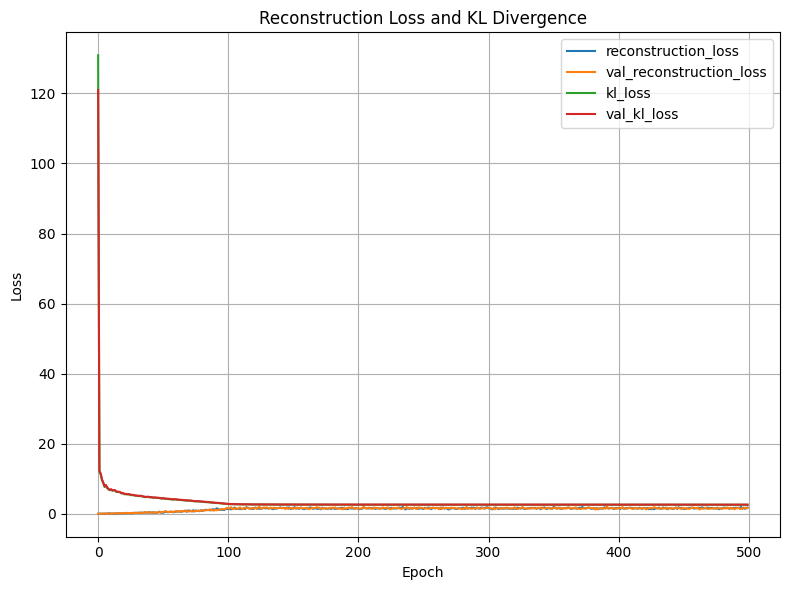

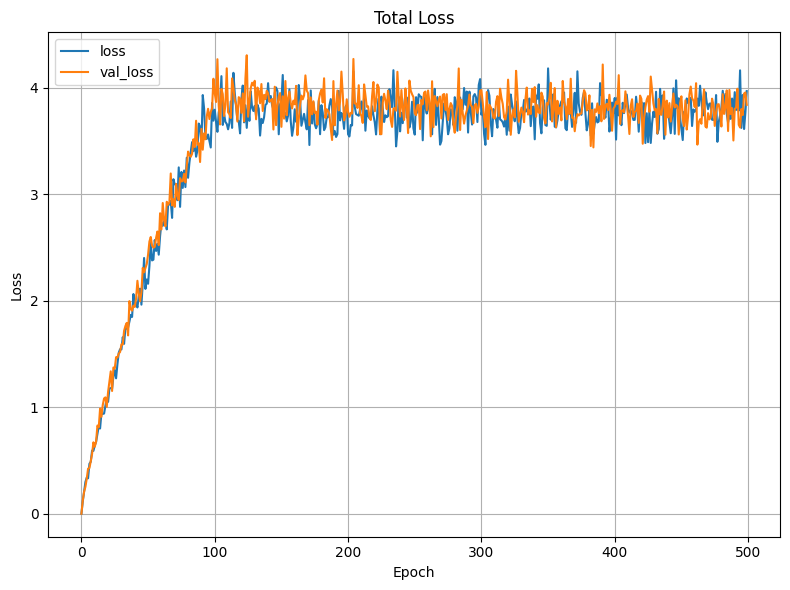

In [15]:
# Plot the training and validation loss curves
plots = Plots(history)
plots.plot_reconstruction_and_kl_divergence()
plots.plot_total_loss()

# Validation: distribuzione generata vs POVM vera

Le loss non dicono se il VAE riproduce la distribuzione corretta. Qui campioniamo dal modello
(`z ~ N(0,I)` -> decoder -> outcome) e confrontiamo la distribuzione empirica generata con quella
esatta `P(a) = Tr[M(a) rho]` tramite la **fidelity classica** `F_c = sum_x sqrt(P(x)*Q(x))` (Eq. 3 del paper).

Riferimento chiave: `F_c(dati di training, esatta)` e' il **tetto** raggiungibile, limitato solo
dallo shot noise dei dati. Se il VAE ci si avvicina, sta facendo il suo lavoro.

=== FIDELITY CLASSICA (floor è ~0.95) ===
  rumore uniforme  vs esatta : 0.9510   <- FLOOR
  VAE              vs esatta : 0.9917   <- MODELLO
  dati training    vs esatta : 0.9998   <- TETTO

=== TOTAL VARIATION (0 = identiche) ===
  rumore uniforme  vs esatta : 0.2585   <- FLOOR
  VAE              vs esatta : 0.1127   <- MODELLO
  dati training    vs esatta : 0.0145   <- TETTO

=== I 4 PICCHI del GHZ ===
  outcome      esatta      VAE  uniforme
  (0, 0, 0)    0.0625   0.0584    0.0156
  (1, 1, 1)    0.0339   0.0255    0.0156
  (2, 2, 2)    0.0339   0.0236    0.0156
  (3, 3, 3)    0.0339   0.0205    0.0156


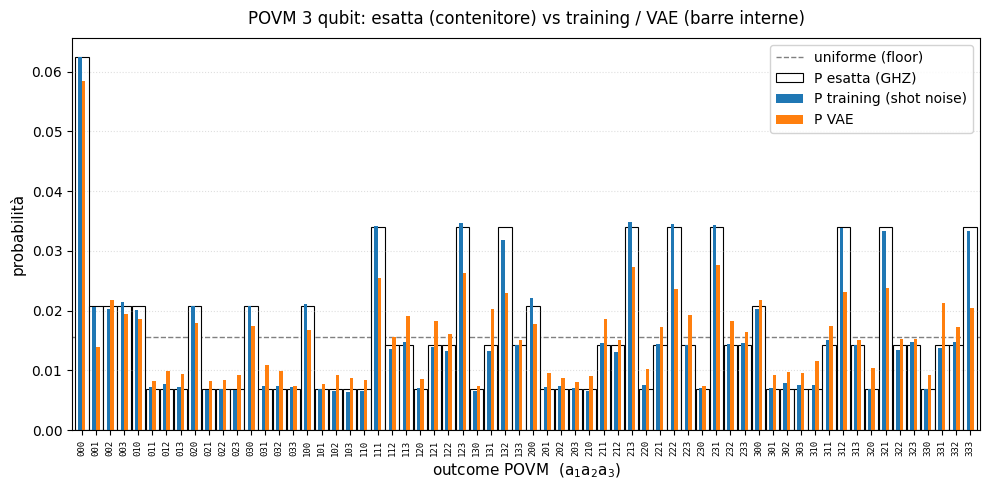

In [ ]:
from povm_sampling import onehot_to_samples

# Calcolo la distribuzione esatta sui 4^N outcomes del POVM (per confronto con il VAE)
P_exact = povm_probability(rho.data, n_qubits)
outcomes = list(P_exact.keys())                  # 4^N outcome ordinati

# Campiono dal VAE e stimo la distribuzione empirica P_vae sui 4^N outcomes
# (fm: istanza del monitor; NON sovrascrivo il nome della classe FidelityMonitor)
fm = FidelityMonitor(P_exact, n_qubits)
gen_samples = fm.vae_generate(model, n_samples=20000)
P_vae = samples_to_empirical_dist(gen_samples, n_qubits)

# Baseline distribuzione uniforme e distribuzione empirica dei dati di training (shot noise)
P_unif = {o: 1.0 / len(outcomes) for o in outcomes}
P_train = samples_to_empirical_dist(onehot_to_samples(X_train, n_qubits), n_qubits)

# Calcolo metriche di confronto: Fidelity classica (coeff. di Bhattacharyya) e Total Variation
# NB: il floor e' uniforme vs ESATTA (cosa ottieni senza imparare nulla), non vs P_vae
classical_fidelity_floor = fm.classical_fidelity(P_unif, P_exact)
total_variation_floor = fm.total_variation(P_unif, P_exact)

classical_fidelity_vae = fm.classical_fidelity(P_vae, P_exact)
total_variation_vae = fm.total_variation(P_vae, P_exact)

classical_fidelity_train = fm.classical_fidelity(P_train, P_exact)
total_variation_train = fm.total_variation(P_train, P_exact)

print("=== FIDELITY CLASSICA (floor è ~0.95) ===")
print(f"  rumore uniforme  vs esatta : {classical_fidelity_floor:.4f}   <- FLOOR")
print(f"  VAE              vs esatta : {classical_fidelity_vae:.4f}   <- MODELLO")
print(f"  dati training    vs esatta : {classical_fidelity_train:.4f}   <- TETTO")
print()
print("=== TOTAL VARIATION (0 = identiche) ===")
print(f"  rumore uniforme  vs esatta : {total_variation_floor:.4f}   <- FLOOR")
print(f"  VAE              vs esatta : {total_variation_vae:.4f}   <- MODELLO")
print(f"  dati training    vs esatta : {total_variation_train:.4f}   <- TETTO")
print()
print("=== I 4 PICCHI del GHZ ===")
print(f"  {'outcome':10s} {'esatta':>8s} {'VAE':>8s} {'uniforme':>9s}")
for o in [(0, 0, 0), (1, 1, 1), (2, 2, 2), (3, 3, 3)]:
    print(f"  {str(o):10s} {P_exact[o]:8.4f} {P_vae.get(o,0):8.4f} {1/len(outcomes):9.4f}")

# --- 4. Confronto visivo sui 64 outcomes (solo 3 qubit): grouped bar chart esatta vs VAE vs training ---
p_true = np.array([P_exact[o]        for o in outcomes])
p_gen  = np.array([P_vae.get(o, 0.0) for o in outcomes])   # .get: il VAE puo' non generare tutti gli outcome
p_train = np.array([P_train.get(o, 0.0) for o in outcomes]) # .get: i dati di training possono non coprire tutti gli outcome

plots.plot_distribution_compare(p_true, p_gen, p_train, outcomes)


# Provo da 3 a 8 qubit

In [ ]:
N_SAMPLES = [1000, 5000, 10000, 20000, 50000]
N_QUBITS = [3, 4, 5, 6, 7]

# geometria (latent_dim, hidden, N_GEN) per numero di qubit
CFG = {
    3: dict(latent_dim=16,  hidden=96,  batch_size=100, N_GEN=20000),
    4: dict(latent_dim=32,  hidden=128,  batch_size=200, N_GEN=100000),
    5: dict(latent_dim=64,  hidden=224,  batch_size=500, N_GEN=4**5 * 500),
    6: dict(latent_dim=256, hidden=1280, batch_size=600, N_GEN=4**6 * 500),
    7: dict(latent_dim=512, hidden=1504, batch_size=800, N_GEN=4**7 * 500),
}

# accumulo i risultati per il plot finale: una curva per ogni numero di qubit
results = {q: {"n_samples": [], "Fc": [], "Fc_train": []} for q in N_QUBITS}

for q in N_QUBITS:
    for n in N_SAMPLES:
        print(f"\n=== N_QUBITS={q}   N_SAMPLES={n} ===")
        n_samples = n
        n_qubits = q

        # GHZ esatto + distribuzione POVM vera
        qc = create_ghz_state(n_qubits)
        rho = DensityMatrix(qc)
        P_exact = povm_probability(rho.data, n_qubits)
        outcomes = list(P_exact.keys())            # ricalcolato per ogni q (era un bug: restava a 3 qubit)

        # campiona la distribuzione e prepara i dati
        sample = sample_povm(P_exact, n_samples=n_samples)
        onehot_sample = samples_to_onehot(sample, n_qubits)
        X_train, X_test = train_test_split(onehot_sample, test_size=0.2, random_state=42)

        cfg = CFG[q]
        latent_dim, hidden, batch_size, N_GEN = cfg["latent_dim"], cfg["hidden"], cfg["batch_size"], cfg["N_GEN"]

        vae = VAE(n_qubits=n_qubits, latent_dim=latent_dim, hidden=hidden)
        vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))
        vae.build(input_shape=(None, 4 * n_qubits))
        model = vae

        WARMUP = 30   # epoche di warm-up della KL (0 -> beta_max)
        callbacks = [
            KLWarmup(beta_max=0.85, warmup_epochs=WARMUP),
            EarlyStopping(monitor='val_loss', mode='min',
                            patience=40, restore_best_weights=True, start_from_epoch=WARMUP),
        ]

        history = model.fit(
            X_train, X_train,
            epochs=2000,
            batch_size=batch_size,
            validation_data=(X_test, X_test),
            callbacks=callbacks,
            verbose=0,
        )

        # campiona dal VAE e calcola le metriche vs la distribuzione esatta
        # (fm: istanza del monitor, espone vae_generate/classical_fidelity/total_variation)
        fm = FidelityMonitor(P_exact, n_qubits, n_gen=N_GEN)
        gen_samples = fm.vae_generate(model, N_GEN)
        P_vae = samples_to_empirical_dist(gen_samples, n_qubits)
        P_train = samples_to_empirical_dist(onehot_to_samples(X_train, n_qubits), n_qubits)
        P_unif = {o: 1.0 / len(outcomes) for o in outcomes}

        Fc        = fm.classical_fidelity(P_vae,   P_exact)
        Fc_train  = fm.classical_fidelity(P_train, P_exact)
        Var       = fm.total_variation(P_vae,   P_exact)
        Var_train = fm.total_variation(P_train, P_exact)
        # Print with minimal informations
        print(f"  Fidelity classica VAE vs esatta : {Fc:.4f}   <- MODELLO")
        print(f"  Fidelity classica training vs esatta : {Fc_train:.4f}   <- TETTO")
        print(f"  Variazione totale VAE vs esatta : {Var:.4f}   <- MODELLO")
        print(f"  Variazione totale training vs esatta : {Var_train:.4f}   <- TETTO")

        # salvo la fidelity classica per il plot al variare di N_SAMPLES e N_QUBITS
        # (atteso: cresce con n_samples, cala con n_qubits)
        results[q]["n_samples"].append(n)
        results[q]["Fc"].append(Fc)
        results[q]["Fc_train"].append(Fc_train)

print("\nRESULTS:", results)


=== N_QUBITS=3   N_SAMPLES=1000 ===
  Fidelity classica VAE vs esatta : 0.9798   <- MODELLO
  Fidelity classica training vs esatta : 0.9860   <- TETTO
  Variazione totale VAE vs esatta : 0.1739   <- MODELLO
  Variazione totale training vs esatta : 0.1183   <- TETTO

=== N_QUBITS=3   N_SAMPLES=5000 ===
  Fidelity classica VAE vs esatta : 0.9913   <- MODELLO
  Fidelity classica training vs esatta : 0.9980   <- TETTO
  Variazione totale VAE vs esatta : 0.1182   <- MODELLO
  Variazione totale training vs esatta : 0.0476   <- TETTO

=== N_QUBITS=3   N_SAMPLES=10000 ===
  Fidelity classica VAE vs esatta : 0.9909   <- MODELLO
  Fidelity classica training vs esatta : 0.9992   <- TETTO
  Variazione totale VAE vs esatta : 0.1206   <- MODELLO
  Variazione totale training vs esatta : 0.0319   <- TETTO

=== N_QUBITS=3   N_SAMPLES=20000 ===
  Fidelity classica VAE vs esatta : 0.9931   <- MODELLO
  Fidelity classica training vs esatta : 0.9995   <- TETTO
  Variazione totale VAE vs esatta : 0.1051   

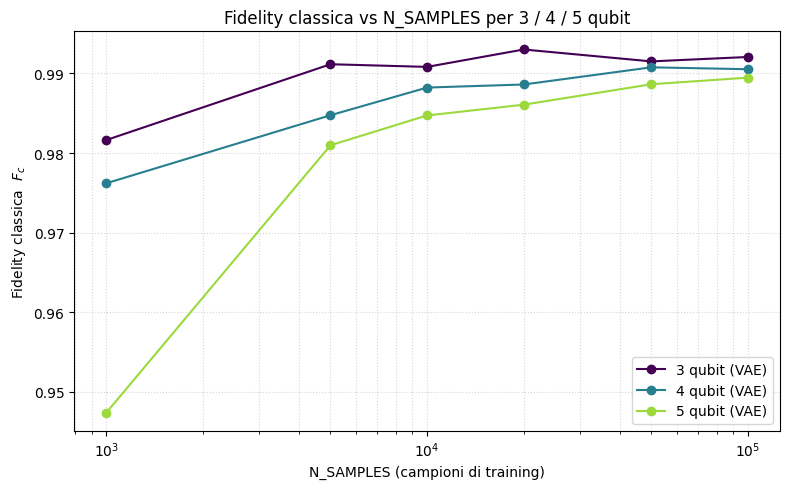

In [ ]:
plots.plot_fidelity_vs_samples(results)